# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.

## 1. Mecanismo de detención de Ascensión de Colinas

El algoritmo de **Ascensión de Colinas** comienza en un estado inicial y, en cada iteración, evalúa sus estados vecinos. Luego se desplaza hacia el vecino que tenga el mejor valor.

Su mecanismo de detención consiste en finalizar cuando **ningún vecino mejora al estado actual**. Es decir, para un problema de maximización, se detiene cuando:

$$
f(s') \leq f(s)
$$

para todo estado vecino $s'$ del estado actual $s$.

El problema es que esta condición solamente considera la región cercana al estado actual. Por lo tanto, el algoritmo puede detenerse aunque todavía exista una solución mejor en otra región del espacio de búsqueda.

Las principales situaciones problemáticas son:

### Máximo local

Es un estado mejor que todos sus vecinos, pero que no corresponde al máximo global del problema. El algoritmo se detiene porque no encuentra una mejora inmediata.

### Meseta

Es una región donde varios estados vecinos tienen el mismo valor:

$$
f(s_1)=f(s_2)=\cdots=f(s_n)
$$

Como no existe una dirección de mejora clara, el algoritmo puede detenerse o desplazarse sin saber hacia dónde avanzar.

### Cresta

Es una región en la que la dirección de crecimiento no coincide directamente con los movimientos permitidos entre estados. Para continuar mejorando sería necesario realizar una combinación de movimientos, pero el algoritmo solamente analiza movimientos individuales.

Por estas razones, la Ascensión de Colinas no garantiza encontrar el máximo global. Algunas posibles mejoras son utilizar reinicios aleatorios, permitir movimientos laterales durante una cantidad limitada de iteraciones o aplicar métodos como el Recocido Simulado.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

## 2. Heurísticas empleadas en un Problema de Satisfacción de Restricciones

En un Problema de Satisfacción de Restricciones se deben tomar dos decisiones:

1. Qué variable asignar primero.
2. Qué valor probar primero para esa variable.

Las principales heurísticas utilizadas son las siguientes.

### Variable más restringida o MRV

La heurística MRV, del inglés *Minimum Remaining Values*, selecciona la variable no asignada que tenga la menor cantidad de valores legales disponibles en su dominio.

Si:

$$
D(X)=\{1\}
$$

y:

$$
D(Y)=\{1,2,3\}
$$

se selecciona primero $X$, porque solamente tiene una opción posible.

Esta estrategia también se conoce como principio de **fallar primero**, ya que permite detectar rápidamente si una variable se quedó sin valores posibles.

### Heurística de grado

La heurística de grado selecciona la variable no asignada que tenga la mayor cantidad de restricciones con otras variables que todavía no fueron asignadas.

En la representación mediante un grafo, se elige el nodo que tenga la mayor cantidad de vecinos todavía no asignados.

La idea es asignar primero la variable que más condiciona a las demás. Generalmente se utiliza para desempatar cuando varias variables tienen la misma cantidad de valores disponibles según MRV.

### Valor menos restrictivo

Una vez seleccionada la variable, esta heurística determina qué valor probar primero.

Se elige el valor que elimine la menor cantidad de opciones de los dominios de las variables vecinas.

Por ejemplo, si asignar un valor $a$ elimina dos opciones de los vecinos y asignar un valor $b$ elimina cinco, se prueba primero $a$.

De esta manera se conserva la mayor cantidad posible de alternativas para completar las asignaciones restantes.

### Orden habitual de aplicación

Las heurísticas pueden combinarse de la siguiente manera:

1. Se aplica MRV para seleccionar la variable con menos valores disponibles.
2. Si existe un empate, se aplica la heurística de grado.
3. Para la variable seleccionada, se prueba primero el valor menos restrictivo.

La Comprobación hacia Adelante no es una heurística de selección, sino una técnica de propagación. Después de realizar una asignación, elimina ese valor de los dominios de las variables vecinas y permite detectar anticipadamente si algún dominio queda vacío.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

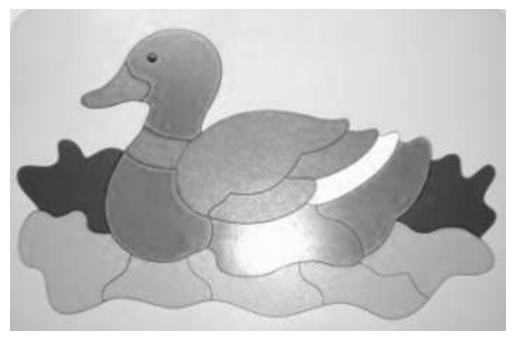

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

## 3. Coloreo del rompecabezas mediante Comprobación hacia Adelante

El problema se representa como un Problema de Satisfacción de Restricciones.

Cada pieza del rompecabezas es una variable y su dominio contiene los siete colores disponibles:

$$
D(P_i)=\{Ro,Ve,Az,Am,Na,Vi,Ce\}
$$

donde:

- $Ro$: rojo.
- $Ve$: verde.
- $Az$: azul.
- $Am$: amarillo.
- $Na$: naranja.
- $Vi$: violeta.
- $Ce$: celeste.

Dos piezas se consideran vecinas cuando comparten un segmento de borde. Si solamente se tocan en un punto, no se consideran vecinas.

La restricción entre dos piezas vecinas es:

$$
P_i\neq P_j
$$

### Identificación de las piezas

Para poder representar claramente el problema, se numeran las piezas de la siguiente manera:

| Pieza | Ubicación |
|---|---|
| $P_1$ | Pico |
| $P_2$ | Cabeza y parte superior del cuello |
| $P_3$ | Franja intermedia del cuello |
| $P_4$ | Pecho |
| $P_5$ | Ala superior grande |
| $P_6$ | Parte inferior del ala |
| $P_7$ | Pluma superior de la cola |
| $P_8$ | Franja blanca de la cola |
| $P_9$ | Parte posterior del cuerpo |
| $P_{10}$ | Parte central inferior del cuerpo |
| $P_{11}$ | Pieza oscura del fondo izquierdo |
| $P_{12}$ | Pieza inferior izquierda del fondo |
| $P_{13}$ | Pieza inferior ubicada debajo del pecho |
| $P_{14}$ | Pieza inferior ubicada debajo del cuerpo |
| $P_{15}$ | Pieza oscura del fondo derecho |
| $P_{16}$ | Pieza inferior derecha del fondo |

### Definición de los vecinos

La relación de vecindad es simétrica. Por ejemplo, si $P_1$ es vecina de $P_2$, entonces $P_2$ también es vecina de $P_1$.

| Pieza | Vecinos |
|---|---|
| $P_1$ | $\{P_2\}$ |
| $P_2$ | $\{P_1,P_3\}$ |
| $P_3$ | $\{P_2,P_4,P_5\}$ |
| $P_4$ | $\{P_3,P_5,P_{10},P_{11},P_{13}\}$ |
| $P_5$ | $\{P_3,P_4,P_6,P_7\}$ |
| $P_6$ | $\{P_5,P_9,P_{10}\}$ |
| $P_7$ | $\{P_5,P_8\}$ |
| $P_8$ | $\{P_7,P_9\}$ |
| $P_9$ | $\{P_6,P_8,P_{10},P_{15},P_{16}\}$ |
| $P_{10}$ | $\{P_4,P_6,P_9,P_{14}\}$ |
| $P_{11}$ | $\{P_4,P_{12}\}$ |
| $P_{12}$ | $\{P_{11},P_{13}\}$ |
| $P_{13}$ | $\{P_4,P_{12},P_{14}\}$ |
| $P_{14}$ | $\{P_{10},P_{13},P_{16}\}$ |
| $P_{15}$ | $\{P_9,P_{16}\}$ |
| $P_{16}$ | $\{P_9,P_{14},P_{15}\}$ |

### Criterio de selección

Se utiliza la heurística de la **Variable más Restringida**, también llamada MRV. En cada paso se selecciona la pieza no coloreada que tenga la menor cantidad de colores disponibles.

Cuando varias piezas tienen la misma cantidad de colores se utilizan estos criterios de desempate:

1. Se selecciona la pieza con más vecinos todavía sin asignar.
2. Si el empate continúa, se selecciona la pieza con el menor número.

Después de asignar un color, la Comprobación hacia Adelante elimina ese color de los dominios de todos sus vecinos todavía no asignados.

### Proceso de búsqueda

Inicialmente:

$$
D(P_i)=\{Ro,Ve,Az,Am,Na,Vi,Ce\}
\qquad\forall P_i
$$

Una posible búsqueda es la siguiente:

| Paso | Pieza seleccionada | Color | Actualización de los vecinos no asignados |
|---:|---|---|---|
| 1 | $P_4$ | $Ro$ | Se elimina $Ro$ de $P_3,P_5,P_{10},P_{11},P_{13}$ |
| 2 | $P_5$ | $Ve$ | $D(P_3)=\{Az,Am,Na,Vi,Ce\}$; se elimina $Ve$ de $P_6$ y $P_7$ |
| 3 | $P_3$ | $Az$ | Se elimina $Az$ de $P_2$ |
| 4 | $P_{10}$ | $Am$ | Se elimina $Am$ de $P_6,P_9,P_{14}$ |
| 5 | $P_6$ | $Na$ | $D(P_9)=\{Ro,Ve,Az,Vi,Ce\}$ |
| 6 | $P_9$ | $Vi$ | Se elimina $Vi$ de $P_8,P_{15},P_{16}$ |
| 7 | $P_{13}$ | $Ce$ | Se elimina $Ce$ de $P_{12}$ y $P_{14}$ |
| 8 | $P_{14}$ | $Ro$ | $D(P_{16})=\{Ve,Az,Am,Na,Ce\}$ |
| 9 | $P_{16}$ | $Ve$ | $D(P_{15})=\{Ro,Az,Am,Na,Ce\}$ |
| 10 | $P_{15}$ | $Ro$ | No quedan vecinos suyos sin asignar |
| 11 | $P_2$ | $Ro$ | Se elimina $Ro$ de $P_1$ |
| 12 | $P_7$ | $Ro$ | $D(P_8)=\{Ve,Az,Am,Na,Ce\}$ |
| 13 | $P_8$ | $Ve$ | No quedan vecinos suyos sin asignar |
| 14 | $P_{11}$ | $Ve$ | $D(P_{12})=\{Ro,Az,Am,Na,Vi\}$ |
| 15 | $P_{12}$ | $Ro$ | No quedan vecinos suyos sin asignar |
| 16 | $P_1$ | $Ve$ | Se completa la asignación |

En ningún paso un dominio queda vacío, por lo que no es necesario realizar backtracking.

### Solución obtenida

| Pieza | Color | Pieza | Color |
|---|---|---|---|
| $P_1$ | Verde | $P_9$ | Violeta |
| $P_2$ | Rojo | $P_{10}$ | Amarillo |
| $P_3$ | Azul | $P_{11}$ | Verde |
| $P_4$ | Rojo | $P_{12}$ | Rojo |
| $P_5$ | Verde | $P_{13}$ | Celeste |
| $P_6$ | Naranja | $P_{14}$ | Rojo |
| $P_7$ | Rojo | $P_{15}$ | Rojo |
| $P_8$ | Verde | $P_{16}$ | Verde |

La asignación es completa y consistente porque todas las piezas tienen un color y ninguna pieza comparte el mismo color con una de sus vecinas.

Esta es solamente una de las posibles soluciones. La búsqueda puede producir otra asignación válida si se modifican los criterios de desempate o el orden en el que se prueban los colores.

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

## 4. Máximo de una función mediante Ascensión de Colinas

Se desea encontrar el máximo de:

$$
f(x)=\frac{\sin(x)}{x+0.1}
$$

en el intervalo:

$$
x\in[-10,-6]
$$

utilizando el algoritmo de **Ascensión de Colinas**.

Para representar el problema se definen los siguientes elementos:

- **Estado:** un valor posible de $x$ dentro del intervalo.
- **Función de evaluación:** el valor de $f(x)$.
- **Estado inicial:** $x=-10$.
- **Vecinos:** los puntos ubicados un paso a la izquierda y a la derecha del estado actual:

$$
x_{\text{izquierdo}}=x-\Delta x
$$

$$
x_{\text{derecho}}=x+\Delta x
$$

- **Movimiento:** se avanza hacia el vecino que tenga el mayor valor de $f(x)$.
- **Detención:** el algoritmo finaliza cuando ninguno de los vecinos mejora el valor del estado actual.

Se utiliza:

$$
\Delta x=0.01
$$

Como el paso es menor que $0.1$, permite obtener la precisión solicitada por el ejercicio.

Los valores que queden fuera del intervalo $[-10,-6]$ no se consideran vecinos válidos.

La función seno de Python trabaja en radianes, que es la unidad utilizada en este ejercicio.

In [3]:
import math


def funcion_objetivo(x):
    """Calcula el valor de la función que se desea maximizar."""
    return math.sin(x) / (x + 0.1)


def ascension_colinas(x_inicial, limite_inferior, limite_superior, paso):
    """Busca un máximo desplazándose hacia el mejor vecino."""
    x_actual = x_inicial
    iteraciones = 0

    while True:
        posibles_vecinos = (
            x_actual - paso,
            x_actual + paso
        )

        vecinos_validos = [
            x
            for x in posibles_vecinos
            if limite_inferior <= x <= limite_superior
        ]

        mejor_vecino = max(vecinos_validos, key=funcion_objetivo)

        if funcion_objetivo(mejor_vecino) <= funcion_objetivo(x_actual):
            return x_actual, funcion_objetivo(x_actual), iteraciones

        x_actual = mejor_vecino
        iteraciones += 1


LIMITE_INFERIOR = -10.0
LIMITE_SUPERIOR = -6.0
PASO = 0.01
X_INICIAL = LIMITE_INFERIOR

x_maximo, valor_maximo, cantidad_iteraciones = ascension_colinas(
    X_INICIAL,
    LIMITE_INFERIOR,
    LIMITE_SUPERIOR,
    PASO
)

print(f"Máximo aproximado en x = {x_maximo:.4f}")
print(f"Valor máximo f(x) = {valor_maximo:.6f}")
print(f"Cantidad de iteraciones = {cantidad_iteraciones}")

Máximo aproximado en x = -7.7200
Valor máximo f(x) = 0.130057
Cantidad de iteraciones = 228


### Resultado

El algoritmo comenzó en:

$$
x=-10
$$

y fue comparando el estado actual con sus dos posibles vecinos:

$$
x-\Delta x
\qquad\text{y}\qquad
x+\Delta x
$$

En cada iteración avanzó hacia el vecino con mayor valor de la función. El proceso se detuvo cuando ninguno de los dos vecinos produjo una mejora.

El máximo aproximado obtenido fue:

$$
x_{\max}\approx-7.72
$$

con un valor de:

$$
f(x_{\max})\approx0.130057
$$

El paso utilizado fue:

$$
\Delta x=0.01<0.1
$$

por lo que se cumple la precisión solicitada. El valor exacto del máximo se encuentra aproximadamente en $x=-7.7236$, de modo que el error de la aproximación obtenida es:

$$
|-7.72-(-7.7236)|\approx0.0036<0.1
$$

En este caso el algoritmo encuentra el máximo de la función dentro del intervalo. Sin embargo, como se estudió en la teoría, la Ascensión de Colinas no garantiza encontrar el máximo global en cualquier problema, ya que puede detenerse en un máximo local.

Verificacion por geogebra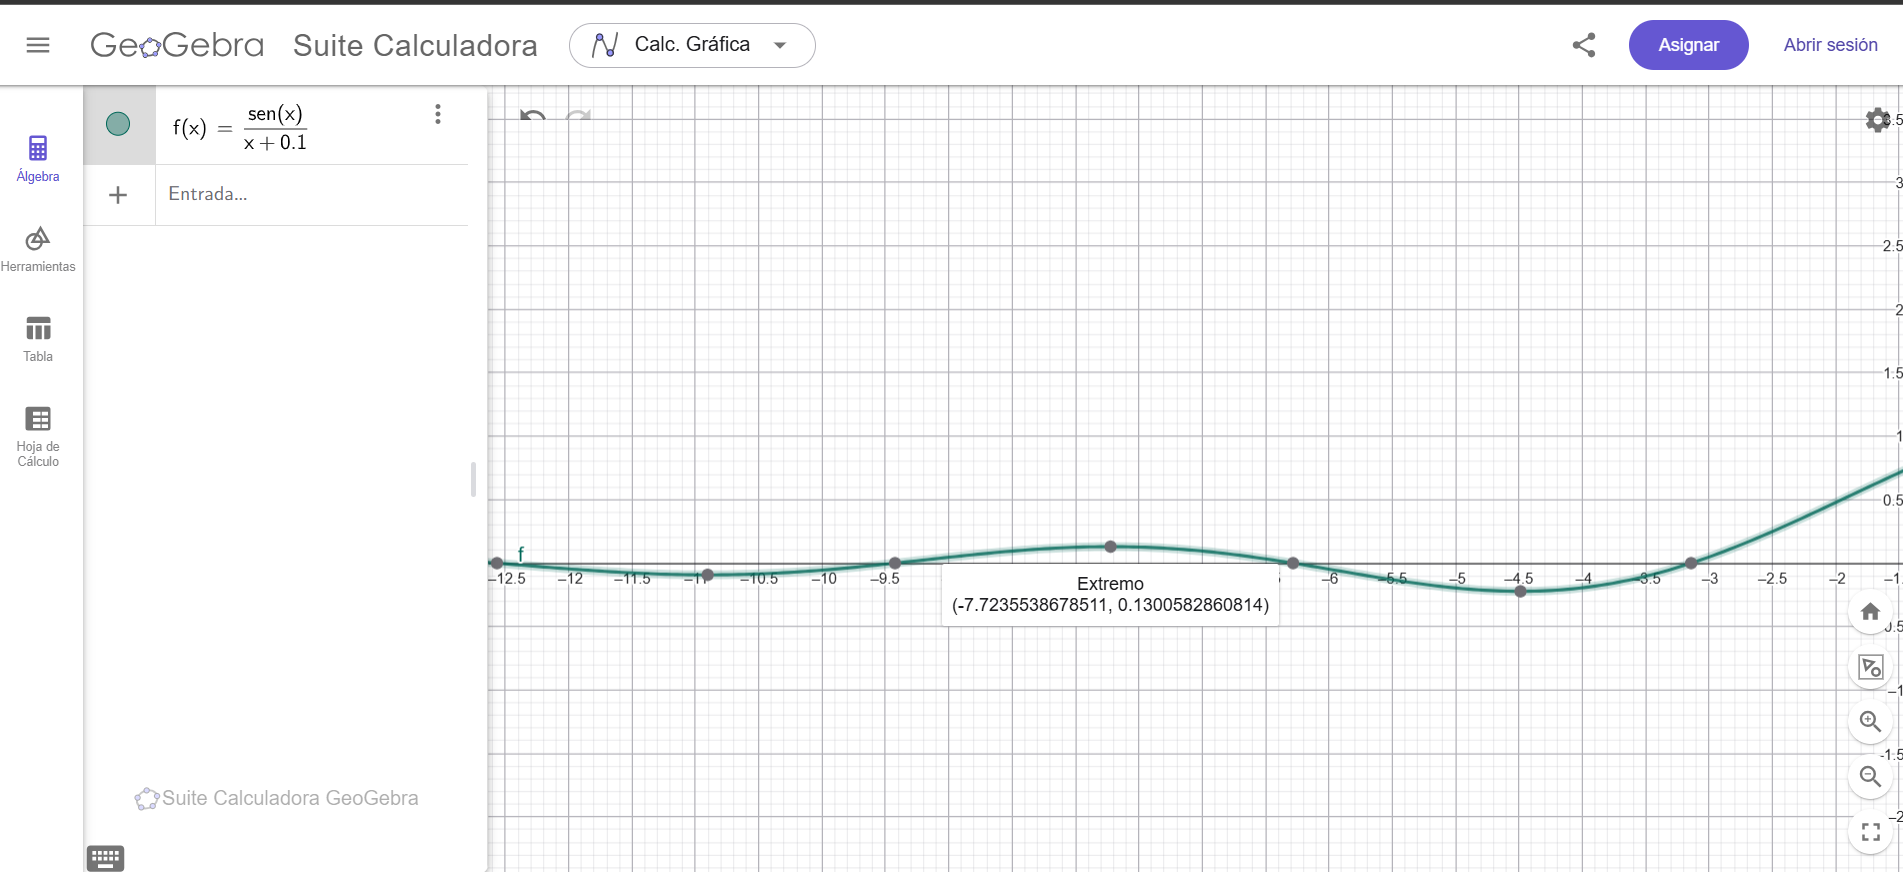

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?

## 5. Ta-te-ti mediante Recocido Simulado

Se implementa un Ta-te-ti en el cual:

- El jugador utiliza la ficha `X`.
- La inteligencia artificial utiliza la ficha `O`.
- El jugador comienza la partida.
- Gana quien coloca tres fichas iguales en una fila, columna o diagonal.
- Si se completa el tablero sin un ganador, la partida termina en empate.

Las casillas se numeran de la siguiente manera:

| 1 | 2 | 3 |
|---|---|---|
| **4** | **5** | **6** |
| **7** | **8** | **9** |

### Decisiones obligatorias

Antes de aplicar Recocido Simulado, la inteligencia artificial verifica:

1. Si puede ganar en ese movimiento, realiza la jugada ganadora.
2. Si el jugador puede ganar en el siguiente movimiento, bloquea esa casilla.
3. Si no existe una jugada obligatoria, aplica Recocido Simulado.

Esta separación evita que la inteligencia artificial ignore una victoria o permita una derrota inmediata debido a una decisión aleatoria.

### Representación de un estado

En cada turno de la inteligencia artificial, un estado representa una posible casilla en la cual podría colocar su ficha.

Por ejemplo, si las casillas disponibles son:

$$
\{2,3,5,7\}
$$

el estado actual podría ser la casilla 3.

El algoritmo comienza seleccionando aleatoriamente una de las casillas disponibles como solución inicial. Esta elección inicial no es necesariamente la jugada que finalmente realizará.

### Definición de los vecinos

Los vecinos de un estado son todas las otras casillas disponibles.

Por ejemplo, si el estado actual es la casilla 3:

$$
s_{\text{actual}}=3
$$

sus vecinos son:

$$
N(s_{\text{actual}})=\{2,5,7\}
$$

En este problema, la palabra “vecino” no significa que las casillas deban estar juntas físicamente en el tablero. Significa que son soluciones alternativas a la jugada actual.

### Evaluación de las posiciones

Cada casilla tiene un valor base según su ubicación:

| Posición | Casillas | Valor base |
|---|---|---:|
| Centro | 5 | 3 |
| Esquinas | 1, 3, 7 y 9 | 2 |
| Bordes | 2, 4, 6 y 8 | 1 |

El centro tiene mayor valor porque participa en cuatro posibles líneas ganadoras. Una esquina participa en tres y un borde solamente en dos.

También se agregan puntos según las líneas que podría formar la inteligencia artificial:

- Dos fichas de la IA y una casilla vacía: `+10`.
- Una ficha de la IA y dos casillas vacías: `+2`.
- Una línea que contenga fichas de ambos jugadores queda bloqueada: `+1`.

En el primer movimiento, con el tablero vacío, los valores son:

| Tipo de casilla | Cálculo | Puntuación |
|---|---:|---:|
| Centro | $3+4\cdot2$ | 11 |
| Esquina | $2+3\cdot2$ | 8 |
| Borde | $1+2\cdot2$ | 5 |

Por lo tanto, aunque la solución inicial sea aleatoria, el centro es la jugada con mayor evaluación.

### Comparación entre el estado actual y un vecino

Se calcula:

$$
\Delta=E(s_{\text{vecino}})-E(s_{\text{actual}})
$$

donde $E(s)$ es la evaluación de la jugada.

Se presentan tres posibilidades:

1. Si $\Delta>0$, el vecino es mejor y siempre se acepta.
2. Si $\Delta=0$, ambos tienen el mismo valor y se acepta el vecino.
3. Si $\Delta<0$, el vecino es peor y se acepta con una probabilidad:

$$
P(\text{aceptar})=e^{\frac{\Delta}{T}}
$$

donde $T$ es la temperatura actual.

Aceptar ocasionalmente una alternativa peor permite explorar diferentes soluciones y evitar que el algoritmo se comporte siempre de manera completamente voraz.

### Parámetros utilizados

| Parámetro | Valor | Función |
|---|---:|---|
| Temperatura inicial baja | $0.1$ | Produce un comportamiento más selectivo |
| Temperatura inicial alta | $20$ | Permite aceptar más alternativas peores |
| Temperatura mínima | $0.01$ | Detiene el algoritmo cuando se alcanza |
| Factor de enfriamiento | $0.90$ | Reduce la temperatura en cada iteración |
| Máximo de iteraciones | $30$ | Evita una búsqueda innecesariamente larga |

La temperatura se actualiza mediante:

$$
T_{\text{nueva}}=0.90\cdot T_{\text{actual}}
$$

Por ejemplo, para una alternativa que empeora la puntuación en una unidad:

$$
\Delta=-1
$$

con temperatura baja:

$$
P=e^{\frac{-1}{0.1}}\approx0.000045
$$

mientras que con temperatura alta:

$$
P=e^{\frac{-1}{20}}\approx0.951
$$

Por eso, una temperatura alta genera un comportamiento más exploratorio y aleatorio, mientras que una temperatura baja favorece rápidamente las jugadas con mayor evaluación.

In [ ]:
import math
import random


# Fichas utilizadas en el juego
JUGADOR = "X"
IA = "O"
VACIA = " "

# Posiciones que producen una victoria
LINEAS_GANADORAS = (
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
)

# Valor base de cada posición:
# esquinas = 2, bordes = 1 y centro = 3
VALOR_POSICION = (2, 1, 2, 1, 3, 1, 2, 1, 2)

# Parámetros del Recocido Simulado
TEMPERATURA_MINIMA = 0.01
FACTOR_ENFRIAMIENTO = 0.90
MAX_ITERACIONES = 30


def mostrar_tablero(tablero):
    """Muestra las fichas y el número de las casillas vacías."""
    casillas = [
        celda if celda != VACIA else str(indice + 1)
        for indice, celda in enumerate(tablero)
    ]

    print()
    print(f" {casillas[0]} | {casillas[1]} | {casillas[2]}")
    print("---+---+---")
    print(f" {casillas[3]} | {casillas[4]} | {casillas[5]}")
    print("---+---+---")
    print(f" {casillas[6]} | {casillas[7]} | {casillas[8]}")
    print()


def movimientos_disponibles(tablero):
    """Devuelve los índices de las casillas que todavía están vacías."""
    return [
        indice
        for indice, celda in enumerate(tablero)
        if celda == VACIA
    ]


def hay_ganador(tablero, ficha):
    """Comprueba si una ficha ocupa alguna línea ganadora."""
    return any(
        all(tablero[posicion] == ficha for posicion in linea)
        for linea in LINEAS_GANADORAS
    )

In [ ]:
def buscar_jugada_inmediata(tablero, ficha):
    """
    Busca una casilla que permita completar una línea ganadora.
    
    Se utiliza tanto para ganar con la IA como para bloquear
    una posible victoria del jugador.
    """
    for movimiento in movimientos_disponibles(tablero):
        tablero_prueba = tablero.copy()
        tablero_prueba[movimiento] = ficha

        if hay_ganador(tablero_prueba, ficha):
            return movimiento

    return None


def evaluar_movimiento(tablero, movimiento):
    """Calcula la puntuación de una posible jugada de la IA."""
    tablero_prueba = tablero.copy()
    tablero_prueba[movimiento] = IA

    # Se comienza con el valor correspondiente a la posición.
    puntuacion = VALOR_POSICION[movimiento]

    for linea in LINEAS_GANADORAS:
        valores = [
            tablero_prueba[posicion]
            for posicion in linea
        ]

        cantidad_ia = valores.count(IA)
        cantidad_vacias = valores.count(VACIA)

        # Se valoran las líneas que todavía puede completar la IA.
        if JUGADOR not in valores:
            if cantidad_ia == 2 and cantidad_vacias == 1:
                puntuacion += 10
            elif cantidad_ia == 1 and cantidad_vacias == 2:
                puntuacion += 2

        # Una línea con fichas de ambos jugadores queda bloqueada.
        if JUGADOR in valores and IA in valores:
            puntuacion += 1

    return puntuacion


def elegir_movimiento_ia(tablero, temperatura_inicial):
    """Selecciona una jugada utilizando Recocido Simulado."""
    if temperatura_inicial <= 0:
        raise ValueError(
            "La temperatura inicial debe ser mayor que cero."
        )

    movimientos = movimientos_disponibles(tablero)

    # Primera prioridad: ganar inmediatamente.
    movimiento_ganador = buscar_jugada_inmediata(tablero, IA)

    if movimiento_ganador is not None:
        print("La IA encontró una jugada ganadora.")
        return movimiento_ganador

    # Segunda prioridad: impedir la victoria inmediata del jugador.
    movimiento_bloqueo = buscar_jugada_inmediata(tablero, JUGADOR)

    if movimiento_bloqueo is not None:
        print("La IA bloqueó una posible victoria.")
        return movimiento_bloqueo

    # Si solamente queda una casilla, no es necesario buscar.
    if len(movimientos) == 1:
        return movimientos[0]

    # Se elige una solución inicial aleatoria.
    movimiento_actual = random.choice(movimientos)
    valor_actual = evaluar_movimiento(
        tablero,
        movimiento_actual
    )

    temperatura = temperatura_inicial
    peores_aceptados = 0
    iteraciones_realizadas = 0

    for _ in range(MAX_ITERACIONES):
        # Los vecinos son las otras casillas disponibles.
        vecinos = [
            movimiento
            for movimiento in movimientos
            if movimiento != movimiento_actual
        ]

        movimiento_vecino = random.choice(vecinos)
        valor_vecino = evaluar_movimiento(
            tablero,
            movimiento_vecino
        )

        diferencia = valor_vecino - valor_actual

        # Una solución mejor o igual siempre se acepta.
        aceptar_vecino = diferencia >= 0

        # Una solución peor se acepta con cierta probabilidad.
        if diferencia < 0:
            probabilidad = math.exp(
                diferencia / temperatura
            )
            aceptar_vecino = random.random() < probabilidad

        if aceptar_vecino:
            if diferencia < 0:
                peores_aceptados += 1

            movimiento_actual = movimiento_vecino
            valor_actual = valor_vecino

        # Se disminuye la temperatura.
        temperatura *= FACTOR_ENFRIAMIENTO
        iteraciones_realizadas += 1

        if temperatura < TEMPERATURA_MINIMA:
            break

    print(
        f"Recocido: T inicial = {temperatura_inicial}, "
        f"puntuación elegida = {valor_actual}, "
        f"alternativas peores aceptadas = {peores_aceptados}, "
        f"iteraciones = {iteraciones_realizadas}."
    )

    return movimiento_actual

In [ ]:
def pedir_movimiento_jugador(tablero):
    """Solicita una casilla válida al jugador."""
    while True:
        try:
            casilla = int(
                input("Seleccione una casilla entre 1 y 9: ")
            )

            movimiento = casilla - 1

            if movimiento not in range(9):
                print("La casilla debe estar entre 1 y 9.")
            elif tablero[movimiento] != VACIA:
                print("Esa casilla ya está ocupada.")
            else:
                return movimiento

        except ValueError:
            print("Debe ingresar un número entero.")


def jugar_partida(temperatura_inicial):
    """Ejecuta una partida completa contra la IA."""
    tablero = [VACIA] * 9

    print("Usted juega con X y la IA juega con O.")
    print(f"Temperatura inicial de la IA: {temperatura_inicial}")

    while True:
        mostrar_tablero(tablero)

        # Turno del jugador.
        movimiento_jugador = pedir_movimiento_jugador(tablero)
        tablero[movimiento_jugador] = JUGADOR

        if hay_ganador(tablero, JUGADOR):
            mostrar_tablero(tablero)
            print("¡Ganó el jugador!")
            break

        if not movimientos_disponibles(tablero):
            mostrar_tablero(tablero)
            print("La partida terminó en empate.")
            break

        # Turno de la inteligencia artificial.
        movimiento_ia = elegir_movimiento_ia(
            tablero,
            temperatura_inicial
        )
        tablero[movimiento_ia] = IA

        print(
            f"La IA eligió la casilla {movimiento_ia + 1}."
        )

        if hay_ganador(tablero, IA):
            mostrar_tablero(tablero)
            print("Ganó la inteligencia artificial.")
            break

        if not movimientos_disponibles(tablero):
            mostrar_tablero(tablero)
            print("La partida terminó en empate.")
            break

### Experimentación con la temperatura inicial

Para observar el efecto de la temperatura se deben jugar varias partidas utilizando, al menos, los siguientes valores:

#### Temperatura baja

$$
T_0=0.1
$$

Con esta temperatura, la probabilidad de aceptar una jugada con menor puntuación es muy pequeña. La inteligencia artificial se comporta de manera más selectiva y normalmente elige el centro o las esquinas.

#### Temperatura alta

$$
T_0=20
$$

Con esta temperatura, la inteligencia artificial acepta con mayor frecuencia jugadas que tienen una evaluación menor. Su comportamiento es más exploratorio y puede seleccionar un borde aunque el centro tenga una puntuación superior.

Para realizar la comparación, se debe ejecutar la siguiente celda varias veces y cambiar la temperatura inicial entre `0.1` y `20`.

Debido a que el algoritmo contiene elecciones aleatorias, una única partida no es suficiente para comparar su comportamiento. Es conveniente jugar varias veces con cada temperatura y observar el valor mostrado en `alternativas peores aceptadas`.

In [ ]:
TEMPERATURA_INICIAL = 0.1

jugar_partida(TEMPERATURA_INICIAL)

In [ ]:
TEMPERATURA_INICIAL = 20

jugar_partida(TEMPERATURA_INICIAL)


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)